In [3]:
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import tifffile

from pathlib import Path


In [10]:
vol_folder = r'D:\NMAR\test_01\nmar_vol'
mask_path = r'D:\NMAR\Case_01_Deliverables\metal_mask\metal_mask.npy'
raw_dcm_path = r"D:\NMAR\case_01_MFOV\pyrecon\raw\case_13_40006_CEUE00388452_wrist_R_UC.dcm"
metal_trace_path = r"D:\NMAR\Case_01_Deliverables\metal_mask\metal_trace.npy"

root_output_dir = Path(r'D:\NMAR\Case_01_Deliverables')
# os.path.join(root_output_dir, "metal_proj.npy")

In [11]:
def interp_1d_over_mask(signal_1d, mask_1d):
    out = signal_1d.copy()
    metal_idx = np.where(mask_1d)[0]
    nonmetal_idx = np.where(~mask_1d)[0]

    if len(metal_idx) == 0:
        return out
    if len(nonmetal_idx) < 2:
        return out

    out[metal_idx] = np.interp(metal_idx, nonmetal_idx, signal_1d[nonmetal_idx])
    return out

def interp_proj_stack(scan, metal_trace):
    out = proj.copy()
    num_views, det_rows, _ = proj.shape

    for v in range(num_views):
        for r in range(det_rows):
            out[v, r] = interp_1d_over_mask(proj[v, r], metal_trace[v, r])

def load_raw_projection_dicom(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    raw_proj = ds.pixel_array.astype(np.float32)
    return ds, raw_proj


vol_hu: (630, 840, 840)
metal_mask: (630, 840, 840)


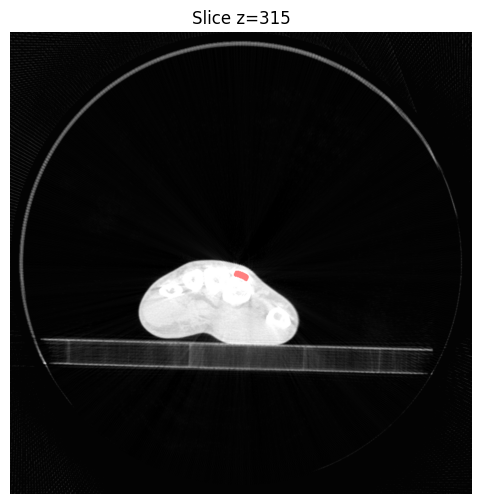

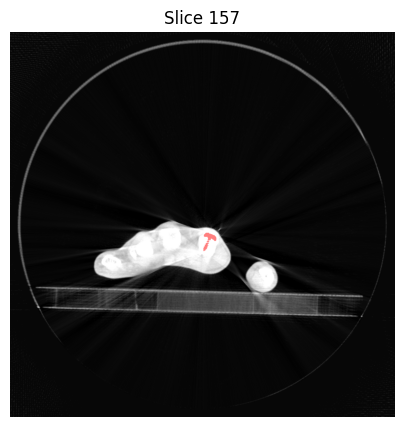

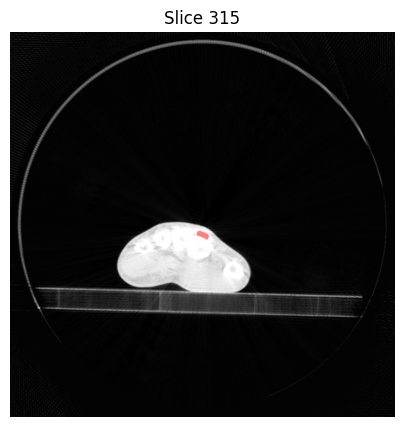

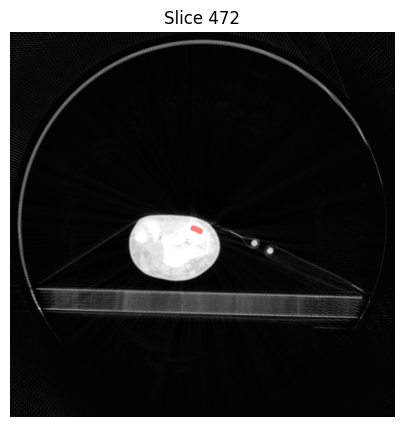

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# paths
# mask_path = os.path.join(mask_dir, "metal_mask.npy")   # or root_output_dir/metal_mask/metal_mask.npy

# load
metal_mask = np.load(mask_path).astype(bool)

print("vol_hu:", vol_hu.shape)
print("metal_mask:", metal_mask.shape)
assert vol_hu.shape == metal_mask.shape, "mask and volume must have same shape"

# choose slice
z = vol_hu.shape[0] // 2

img = vol_hu[z]
mask = metal_mask[z]

# display scaling
p1, p99 = np.percentile(img, (1, 99))
img_norm = np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)

# rgb overlay
rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)

alpha = 0.5
rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"Slice z={z}")
plt.axis("off")
plt.show()

for z in [vol_hu.shape[0]//4, vol_hu.shape[0]//2, 3*vol_hu.shape[0]//4]:
    img = vol_hu[z]
    mask = metal_mask[z]

    p1, p99 = np.percentile(img, (1, 99))
    img_norm = np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)

    rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
    alpha = 0.5
    rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
    rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
    rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.title(f"Slice {z}")
    plt.axis("off")
    plt.show()

In [15]:
   # # # 6) Linear interpolation MAR in projection space
proj_li = interp_proj_stack(vol_hu, metal_mask)
np.save(os.path.join(out_dir, "proj_li.npy"), proj_li)

# pick a representative projection
v = proj_log.shape[0] // 2

raw = proj_log[v]
li  = proj_li[v]
diff = li - raw

# normalize for display
def normalize(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1 + 1e-6), 0, 1)

raw_n = normalize(raw)
li_n  = normalize(li)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Raw (log)")
plt.imshow(raw_n, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("LI")
plt.imshow(li_n, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference (LI - Raw)")
plt.imshow(diff, cmap='bwr')
plt.colorbar()
plt.axis('off')

plt.tight_layout()

# save
out_path = os.path.join(out_dir, f"proj_li_debug_view_{v}.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved: {out_path}")


NameError: name 'proj_log' is not defined

## Not Using


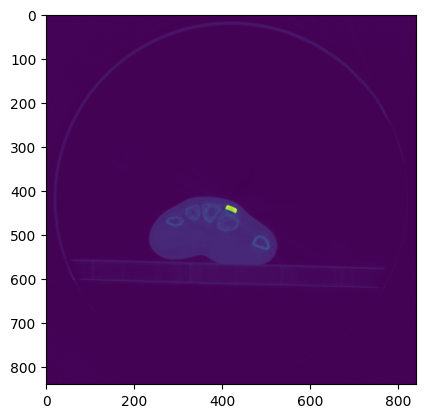

In [12]:
def load_dicom_series_hu(folder):
    slices = []

    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            ds = pydicom.dcmread(path)
            slices.append(ds)
        except:
            continue

    # sort slices (important)
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # stack raw pixel data
    vol = np.stack([s.pixel_array for s in slices]).astype(np.float32)

    # apply HU scaling
    slope = getattr(slices[0], "RescaleSlope", 1.0)
    intercept = getattr(slices[0], "RescaleIntercept", 0.0)

    vol_hu = vol * slope + intercept
    return vol_hu, slices

# ---- usage ----
# folder = "path/to/dicom_dir"
vol_hu, slices = load_dicom_series_hu(vol_folder)


z = vol_hu.shape[0] // 2
plt.imshow(vol_hu[z])